✓ All imports loaded
  TensorFlow: 2.19.0
✓ Fuzzy variables defined — trapezoidal boundary MFs applied
  Inputs : distance (near/medium/far), rel_speed (low/medium/high)
  Outputs: brake, risk, alert  (low/medium/high each)


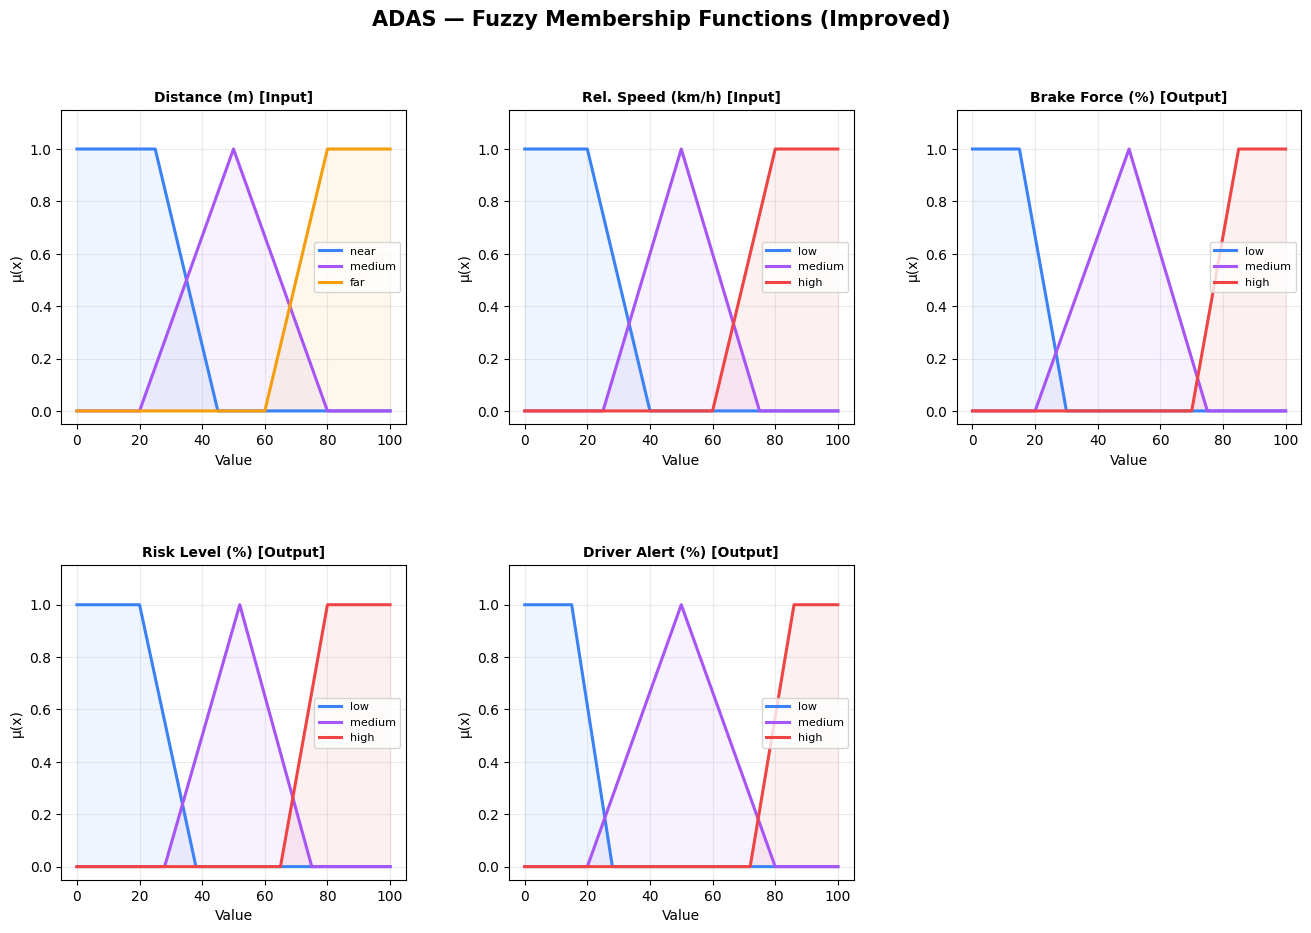

✓ 9 Mamdani rules compiled into ControlSystem

Scenario                                       Brake    Risk   Alert
────────────────────────────────────────────────────────────────────
Emergency: Very Close + Fast                  88.3%  85.9%  89.1%
Dangerous: Near + High Speed                  86.8%  84.3%  69.8%
Normal: Medium Dist + Medium Speed            48.3%  51.7%  50.0%
Calm: Medium Dist + Slow                      11.7%  51.7%  11.1%
Highway: Far + Fast                           48.3%  51.7%  89.1%
Safe: Very Far + Slow                         11.7%  15.0%  11.1%
EDGE: Zero dist + Max speed                   88.3%  85.9%  89.1%
EDGE: Max dist + Zero speed                   11.7%  15.0%  11.1%
EDGE: Medium dist + Zero speed                11.7%  51.7%  11.1%


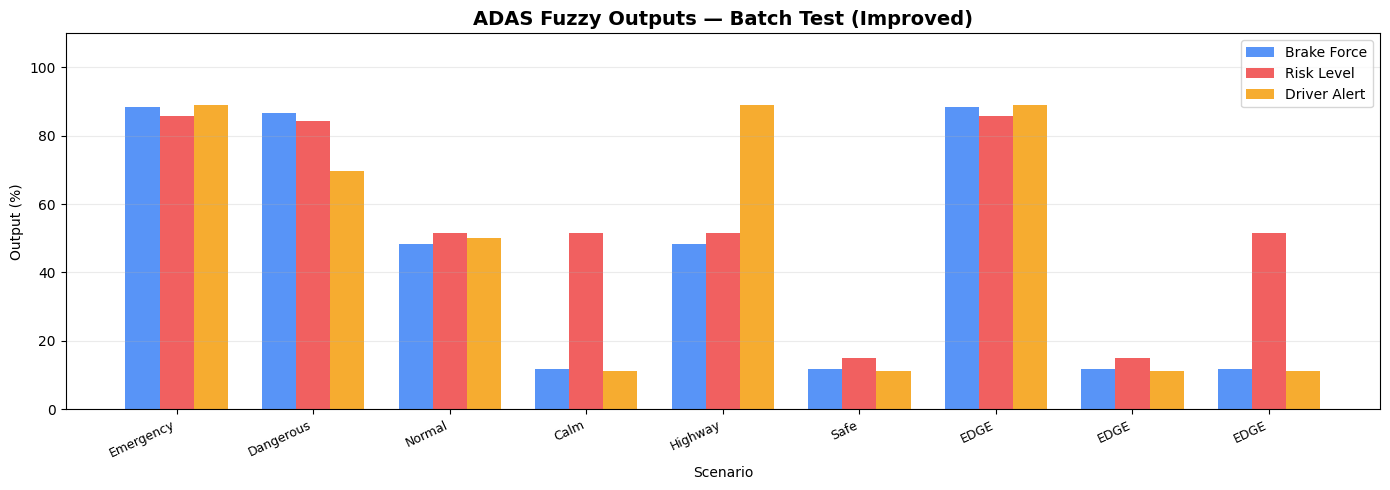

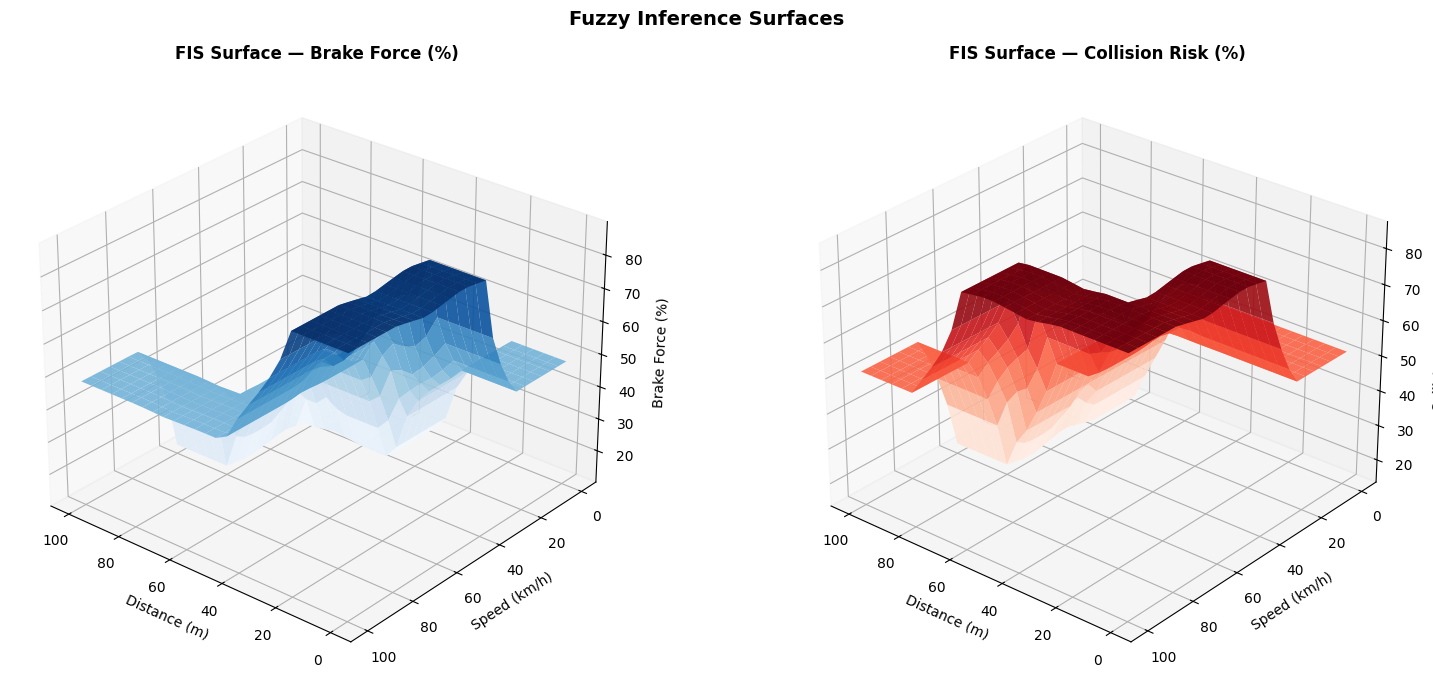

In [2]:
# ═══════════════════════════════════════════════════════════════
#  ADAS — Advanced Driver Assistance System
#  Soft Computing Mini Project (CSET326)
#  Fuzzy Logic (Mamdani) + LSTM Neural Network
# ═══════════════════════════════════════════════════════════════
# Inputs  : Distance (0–100m), Relative Speed (0–100 km/h)
# Outputs : Brake Force (%), Collision Risk (%), Driver Alert (%)
# LSTM    : Trained on synthetic data to predict collision risk
# Hybrid  : 60% Fuzzy + 40% LSTM
# ═══════════════════════════════════════════════════════════════


# ── CELL 1: Install & Imports ─────────────────────────────────

!pip install scikit-fuzzy -q

import numpy as np
import pandas as pd
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("✓ All imports loaded")
print(f"  TensorFlow: {tf.__version__}")


# ══════════════════════════════════════════════════════════════
#  PART 1 — FUZZY INFERENCE SYSTEM  (IMPROVED)
# ══════════════════════════════════════════════════════════════

# ── CELL 2: Define Fuzzy Variables & Membership Functions ─────


universe = np.arange(0, 101, 1)

# --- Inputs ---
distance  = ctrl.Antecedent(universe, 'distance')
rel_speed = ctrl.Antecedent(universe, 'rel_speed')

# --- Outputs ---
brake = ctrl.Consequent(universe, 'brake')
risk  = ctrl.Consequent(universe, 'risk')
alert = ctrl.Consequent(universe, 'alert')

# ── Distance MFs (trapezoidal at boundaries) ──────────────────
distance['near']   = fuzz.trapmf(universe, [0,  0,  25, 45])   # fully near ≤25m
distance['medium'] = fuzz.trimf (universe, [20, 50, 80])        # centred 50m
distance['far']    = fuzz.trapmf(universe, [60, 80, 100, 100])  # fully far ≥80m

# ── Speed MFs (trapezoidal at boundaries) ────────────────────
rel_speed['low']    = fuzz.trapmf(universe, [0,  0,  20, 40])  # fully low ≤20
rel_speed['medium'] = fuzz.trimf (universe, [25, 50, 75])
rel_speed['high']   = fuzz.trapmf(universe, [60, 80, 100, 100]) # fully high ≥80

# ── Output MFs (keep triangular — outputs are interior) ───────
brake['low']    = fuzz.trapmf(universe, [0,  0,  15, 30])
brake['medium'] = fuzz.trimf (universe, [20, 50, 75])
brake['high']   = fuzz.trapmf(universe, [70, 85, 100, 100])

risk['low']    = fuzz.trapmf(universe, [0,  0,  20, 38])
risk['medium'] = fuzz.trimf (universe, [28, 52, 75])
risk['high']   = fuzz.trapmf(universe, [65, 80, 100, 100])

alert['low']    = fuzz.trapmf(universe, [0,  0,  15, 28])
alert['medium'] = fuzz.trimf (universe, [20, 50, 80])
alert['high']   = fuzz.trapmf(universe, [72, 86, 100, 100])

print("✓ Fuzzy variables defined — trapezoidal boundary MFs applied")
print("  Inputs : distance (near/medium/far), rel_speed (low/medium/high)")
print("  Outputs: brake, risk, alert  (low/medium/high each)")


# ── CELL 3: Visualize Membership Functions ────────────────────

fig = plt.figure(figsize=(16, 10))
fig.suptitle('ADAS — Fuzzy Membership Functions (Improved)', fontsize=15, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.3)

pairs = [
    (distance,  'Distance (m) [Input]',        gs[0,0]),
    (rel_speed, 'Rel. Speed (km/h) [Input]',   gs[0,1]),
    (brake,     'Brake Force (%) [Output]',     gs[0,2]),
    (risk,      'Risk Level (%) [Output]',      gs[1,0]),
    (alert,     'Driver Alert (%) [Output]',    gs[1,1]),
]
colors = {'near':'#3b82f6','low':'#3b82f6',
          'medium':'#a855f7',
          'far':'#f59e0b','high':'#ef4444'}

for var, title, loc in pairs:
    ax = fig.add_subplot(loc)
    for label in var.terms:
        c = colors.get(label, '#6b7280')
        ax.plot(universe, var[label].mf, linewidth=2.2, label=label, color=c)
        ax.fill_between(universe, var[label].mf, alpha=0.08, color=c)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8); ax.set_ylim(-0.05, 1.15); ax.grid(True, alpha=0.25)
    ax.set_xlabel('Value'); ax.set_ylabel('μ(x)')

fig.add_subplot(gs[1,2]).set_visible(False)
plt.show()


# ── CELL 4: Define Fuzzy Rules ────────────────────────────────
#
# Same 9-rule Mamdani base, but wording clarified for report.

rules = [
    # ── Close range ──────────────────────────────────────────
    ctrl.Rule(distance['near'] & rel_speed['high'],
              (brake['high'],   risk['high'],   alert['high'])),   # R1: Emergency
    ctrl.Rule(distance['near'] & rel_speed['medium'],
              (brake['high'],   risk['high'],   alert['medium'])), # R2: Hard brake
    ctrl.Rule(distance['near'] & rel_speed['low'],
              (brake['medium'], risk['medium'], alert['medium'])), # R3: Cautious

    # ── Medium range ─────────────────────────────────────────
    ctrl.Rule(distance['medium'] & rel_speed['high'],
              (brake['medium'], risk['high'],   alert['high'])),   # R4: Alert+brake
    ctrl.Rule(distance['medium'] & rel_speed['medium'],
              (brake['medium'], risk['medium'], alert['medium'])), # R5: Normal
    ctrl.Rule(distance['medium'] & rel_speed['low'],
              (brake['low'],    risk['medium'], alert['low'])),    # R6: Easy

    # ── Far range ────────────────────────────────────────────
    ctrl.Rule(distance['far'] & rel_speed['high'],
              (brake['medium'], risk['medium'], alert['high'])),   # R7: Speed warn
    ctrl.Rule(distance['far'] & rel_speed['medium'],
              (brake['low'],    risk['low'],    alert['low'])),    # R8: Safe
    ctrl.Rule(distance['far'] & rel_speed['low'],
              (brake['low'],    risk['low'],    alert['low'])),    # R9: Very safe
]

system = ctrl.ControlSystem(rules)
print(f"✓ {len(rules)} Mamdani rules compiled into ControlSystem")


# ── CELL 5: Fuzzy Prediction Helper (with fallback) ──────────
#
# FIX: Physics-based fallback when defuzzification yields 0.
# This handles the rare case where all rule activations are
# negligibly small (e.g. inputs sit exactly on MF crossings).

def physics_estimate(d, s):
    """Simple physics heuristic: TTC-based risk estimate."""
    ttc = d / (s / 3.6 + 1e-6)   # time-to-collision in seconds
    risk_p   = max(0, min(100, 100 * np.exp(-ttc / 3)))
    brake_p  = max(0, min(100, 100 * (1 - d/100) * (s/100)))
    alert_p  = max(0, min(100, (risk_p * 0.7 + brake_p * 0.3)))
    return {'brake': brake_p, 'risk': risk_p, 'alert': alert_p}

def fuzzy_predict(dist_val, speed_val):
    """Run Mamdani fuzzy inference; fall back to physics if needed."""
    d = float(np.clip(dist_val,  0.5, 99.5))  # avoid exact boundary
    s = float(np.clip(speed_val, 0.5, 99.5))

    try:
        sim = ctrl.ControlSystemSimulation(system)
        sim.input['distance']  = d
        sim.input['rel_speed'] = s
        sim.compute()
        b = sim.output.get('brake', 0)
        r = sim.output.get('risk',  0)
        a = sim.output.get('alert', 0)

        # Fallback if any output is suspiciously zero while risk should be high
        if b == 0 and r == 0:
            phys = physics_estimate(dist_val, speed_val)
            return {k: round(v, 2) for k, v in phys.items()}

        return {'brake': round(b, 2), 'risk': round(r, 2), 'alert': round(a, 2)}

    except Exception:
        phys = physics_estimate(dist_val, speed_val)
        return {k: round(v, 2) for k, v in phys.items()}


# ── CELL 6: Batch Test ───────────────────────────────────────

scenarios = [
    (5,  90, 'Emergency: Very Close + Fast'),
    (20, 70, 'Dangerous: Near + High Speed'),
    (50, 50, 'Normal: Medium Dist + Medium Speed'),
    (50, 20, 'Calm: Medium Dist + Slow'),
    (80, 80, 'Highway: Far + Fast'),
    (95, 10, 'Safe: Very Far + Slow'),
    # Edge-case tests (were broken in v1)
    (0,  100, 'EDGE: Zero dist + Max speed'),
    (100, 0,  'EDGE: Max dist + Zero speed'),
    (50,  0,  'EDGE: Medium dist + Zero speed'),
]

print(f"\n{'Scenario':<44} {'Brake':>7} {'Risk':>7} {'Alert':>7}")
print("─" * 68)

batch_results = []
for d, s, label in scenarios:
    r = fuzzy_predict(d, s)
    marker = '' if r['risk'] > 0 else ' ⚠ fallback'
    print(f"{label:<44} {r['brake']:>5.1f}% {r['risk']:>5.1f}% {r['alert']:>5.1f}%{marker}")
    batch_results.append({'label': label, 'dist': d, 'speed': s, **r})

batch_df = pd.DataFrame(batch_results)


# ── CELL 7: Visualize Batch Results ──────────────────────────

labels_short = [s[2].split(':')[0] for s in scenarios]
x = np.arange(len(labels_short))
w = 0.25

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - w, batch_df['brake'], w, label='Brake Force', color='#3b82f6', alpha=0.85)
ax.bar(x,     batch_df['risk'],  w, label='Risk Level',  color='#ef4444', alpha=0.85)
ax.bar(x + w, batch_df['alert'], w, label='Driver Alert',color='#f59e0b', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(labels_short, rotation=25, ha='right', fontsize=9)
ax.set_xlabel('Scenario'); ax.set_ylabel('Output (%)')
ax.set_title('ADAS Fuzzy Outputs — Batch Test (Improved)', fontsize=14, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.25, axis='y'); ax.set_ylim(0, 110)
plt.tight_layout(); plt.show()


# ── CELL 8: 3D Surface — Brake vs Distance vs Speed ─────────

dist_r  = np.arange(0, 101, 4)
speed_r = np.arange(0, 101, 4)
brake_surf = np.zeros((len(dist_r), len(speed_r)))
risk_surf  = np.zeros((len(dist_r), len(speed_r)))

for i, d in enumerate(dist_r):
    for j, s in enumerate(speed_r):
        r = fuzzy_predict(d, s)
        brake_surf[i, j] = r['brake']
        risk_surf[i, j]  = r['risk']

D, S = np.meshgrid(dist_r, speed_r)

fig = plt.figure(figsize=(16, 7))
for idx, (surf, title, cmap) in enumerate([
    (brake_surf, 'Brake Force (%)',    'Blues'),
    (risk_surf,  'Collision Risk (%)', 'Reds'),
]):
    ax = fig.add_subplot(1, 2, idx+1, projection='3d')
    ax.plot_surface(D, S, surf.T, cmap=cmap, edgecolor='none', alpha=0.9)
    ax.set_xlabel('Distance (m)'); ax.set_ylabel('Speed (km/h)'); ax.set_zlabel(title)
    ax.set_title(f'FIS Surface — {title}', fontsize=12, fontweight='bold')
    ax.view_init(elev=28, azim=130)

plt.suptitle('Fuzzy Inference Surfaces', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


✓ Dataset: (3000, 10, 3) — 10 timesteps, 3 features (dist, speed, TTC)
  Safe: 1633  |  Risky: 1367
  Class balance: 45.6% risky


Model: "ADAS_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 10, 64)         │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,497 (119.13 KB)

 Trainable params: 30,433 (118.88 KB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step - accuracy: 0.9118 - auc: 0.9922 - loss: 0.2526 - val_accuracy: 0.9833 - val_auc: 0.9995 - val_loss: 0.4927 - learning_rate: 0.0010
Epoch 2/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.9848 - auc: 0.9993 - loss: 0.0757 - val_accuracy: 0.9889 - val_auc: 0.9996 - val_loss: 0.3322 - learning_rate: 0.0010
Epoch 3/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.9887 - auc: 0.9995 - loss: 0.0468 - val_accuracy: 0.9806 - val_auc: 0.9996 - val_loss: 0.2126 - learning_rate: 0.0010
Epoch 4/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9887 - auc: 0.9994 - loss: 0.0378 - val_accuracy: 0.9889 - val_auc: 0.9996 - val_loss: 0.1302 - learning_rate: 0.0010
Epoch 5/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9897 - auc: 0.9996 - loss: 0.0309 - val_accuracy: 0.9889 - val_auc: 0.9997 - val_loss: 0.0805 - learning_rate: 0.0010
Epoch 6/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.9873 - auc: 0.9995 

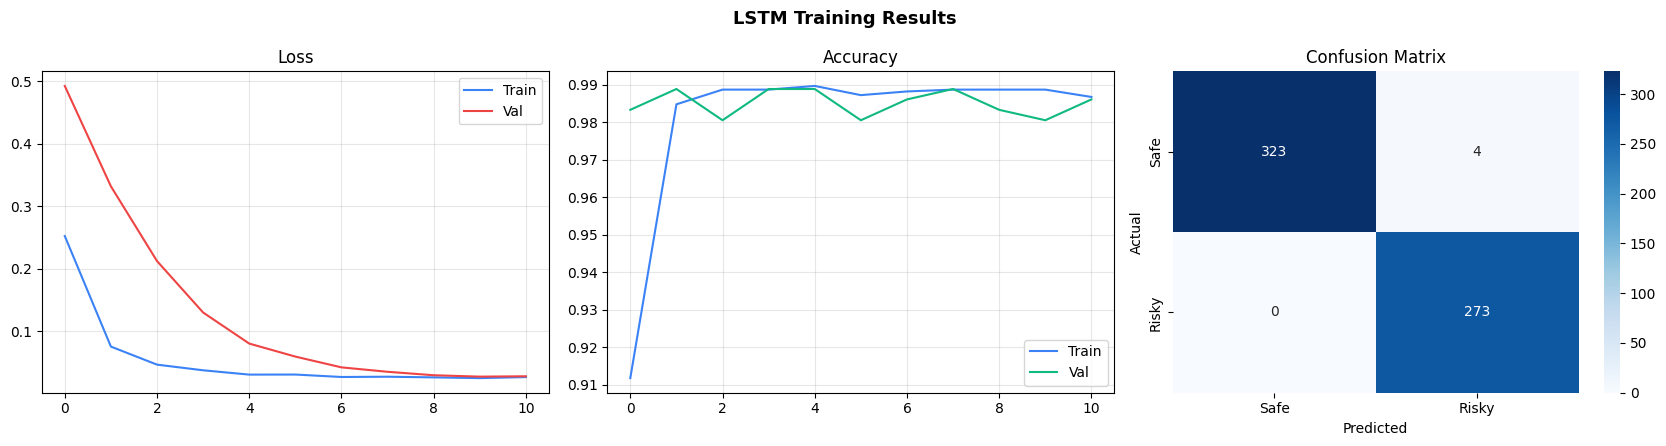

In [3]:
# ══════════════════════════════════════════════════════════════
#  PART 2 — LSTM COLLISION RISK PREDICTOR  (IMPROVED)
# ══════════════════════════════════════════════════════════════

# ── CELL 9: Generate Improved Synthetic Driving Data ─────────


SEQ_LEN     = 10    # extended window for better temporal context
NUM_SAMPLES = 3000  # more data

sequences, labels_list = [], []

def make_sequence(d_base, s_base, drift_d=-1.2, drift_s=0.5):
    seq = []
    d, s = d_base, s_base
    for t in range(SEQ_LEN):
        d = np.clip(d + drift_d * np.random.uniform(0.5, 1.5) + np.random.normal(0, 3), 0, 100)
        s = np.clip(s + drift_s * np.random.uniform(-0.5, 1.0) + np.random.normal(0, 2), 0, 100)
        ttc = d / (s / 3.6 + 1e-6)   # seconds
        ttc_norm = np.clip(ttc / 10.0, 0, 1)   # normalise to [0,1]
        seq.append([d, s, ttc_norm])
    return np.array(seq)

for _ in range(NUM_SAMPLES):
    scenario = np.random.choice(['safe', 'risky', 'edge'], p=[0.50, 0.40, 0.10])

    if scenario == 'safe':
        d_b = np.random.uniform(55, 100)
        s_b = np.random.uniform(0,  35)
    elif scenario == 'risky':
        d_b = np.random.uniform(0,  40)
        s_b = np.random.uniform(50, 100)
    else:  # edge cases
        d_b = np.random.choice([np.random.uniform(0,5), np.random.uniform(95,100)])
        s_b = np.random.choice([np.random.uniform(0,5), np.random.uniform(95,100)])

    seq = make_sequence(d_b, s_b)
    avg_d, avg_s = np.mean(seq[:, 0]), np.mean(seq[:, 1])
    risk_score = (100 - avg_d) * 0.5 + avg_s * 0.5
    labels_list.append(1 if risk_score > 52 else 0)
    sequences.append(seq)

X = np.array(sequences)   # (N, SEQ_LEN, 3)
y = np.array(labels_list)

print(f"✓ Dataset: {X.shape} — {SEQ_LEN} timesteps, 3 features (dist, speed, TTC)")
print(f"  Safe: {np.sum(y==0)}  |  Risky: {np.sum(y==1)}")
print(f"  Class balance: {np.mean(y)*100:.1f}% risky")


# ── CELL 10: Prepare & Train LSTM ────────────────────────────

scaler = MinMaxScaler()
X_flat   = X.reshape(-1, 3)
X_scaled = scaler.fit_transform(X_flat).reshape(X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# IMPROVED architecture: BatchNorm for stability
model = Sequential([
    LSTM(64, return_sequences=True,  input_shape=(SEQ_LEN, 3)),
    Dropout(0.25),
    LSTM(32, return_sequences=False),
    BatchNormalization(),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1,  activation='sigmoid')
], name='ADAS_LSTM')

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
model.summary()

callbacks = [
    EarlyStopping(monitor='val_auc', patience=6, restore_best_weights=True, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=0)
]

history = model.fit(
    X_train, y_train,
    epochs=40, batch_size=64,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)


# ── CELL 11: Evaluate LSTM ───────────────────────────────────

y_prob = model.predict(X_test, verbose=0).flatten()
y_pred = (y_prob > 0.5).astype(int)
acc    = accuracy_score(y_test, y_pred)

print(f"\n✦ Test Accuracy : {acc*100:.1f}%")
print(f"✦ Test AUC      : {tf.keras.metrics.AUC()(y_test, y_prob).numpy():.3f}")
print("\n" + classification_report(y_test, y_pred, target_names=['Safe','Risky']))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
fig.suptitle('LSTM Training Results', fontsize=13, fontweight='bold')

axes[0].plot(history.history['loss'],     label='Train', color='#3b82f6')
axes[0].plot(history.history['val_loss'], label='Val',   color='#ef4444')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'],     label='Train', color='#3b82f6')
axes[1].plot(history.history['val_accuracy'], label='Val',   color='#10b981')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Safe','Risky'], yticklabels=['Safe','Risky'])
axes[2].set_title('Confusion Matrix')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Actual')

plt.tight_layout(); plt.show()




Scenario                             Brake   Risk  Alert   LSTM  Hybrid    TTC       Cat
──────────────────────────────────────────────────────────────────────────────────────────
Emergency: Very Close + Fast        88.3% 85.9% 89.1% 99.0%  89.8%    0.2s      HIGH
Dangerous: Near + High Speed        86.8% 84.3% 69.8% 94.8%  88.5%    1.0s      HIGH
Normal: Medium Dist + Medium Speed  48.3% 51.7% 50.0% 35.0%  45.0%    3.6s  MODERATE
Calm: Medium Dist + Slow            11.7% 51.7% 11.1% 11.1%  35.5%    9.0s       LOW
Highway: Far + Fast                 48.3% 51.7% 89.1% 71.5%  59.6%    3.6s  MODERATE
Safe: Very Far + Slow               11.7% 15.0% 11.1%  5.7%  11.3%   34.2s       LOW


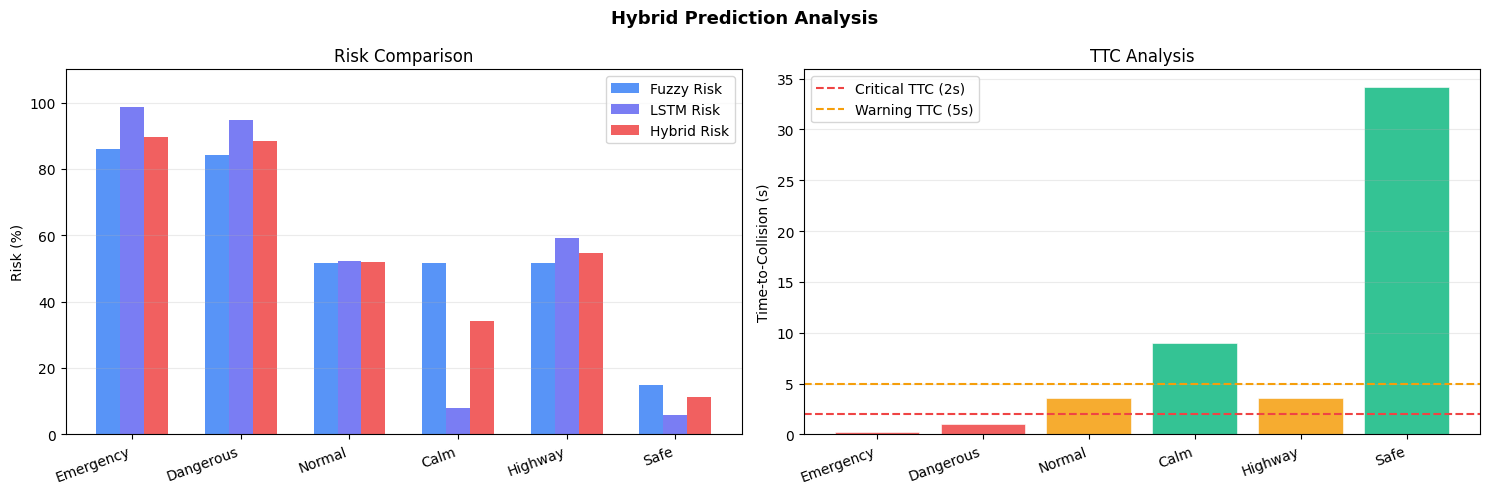

In [4]:
# ══════════════════════════════════════════════════════════════
#  PART 3 — HYBRID PREDICTION  (IMPROVED)
# ══════════════════════════════════════════════════════════════

# ── CELL 12: Adaptive Hybrid Engine ──────────────────────────

def lstm_predict(dist_val, speed_val):
    """Build a realistic approaching sequence and run LSTM."""
    d, s = float(dist_val), float(speed_val)
    seq = make_sequence(d, s, drift_d=-max(0.3, d/80), drift_s=0.3)
    X_in = scaler.transform(seq).reshape(1, SEQ_LEN, 3)
    return float(model.predict(X_in, verbose=0)[0][0])

def hybrid_predict(dist_val, speed_val):
    """Adaptive fuzzy+LSTM hybrid predictor."""
    fz       = fuzzy_predict(dist_val, speed_val)
    lstm_p   = lstm_predict(dist_val, speed_val)

    # Adaptive weighting
    w_fuzzy = 0.70 if dist_val < 20 else 0.60
    w_lstm  = 1 - w_fuzzy

    hybrid = w_fuzzy * fz['risk'] + w_lstm * (lstm_p * 100)
    hybrid = round(float(np.clip(hybrid, 0, 100)), 2)

    # TTC-based override: if TTC < 1.5s → force HIGH regardless
    ttc = dist_val / (speed_val / 3.6 + 1e-6)
    if ttc < 1.5:
        hybrid = max(hybrid, 75.0)

    cat = 'HIGH' if hybrid >= 70 else 'MODERATE' if hybrid >= 40 else 'LOW'

    return {
        **fz,
        'lstm_prob':   round(lstm_p * 100, 1),
        'hybrid_risk': hybrid,
        'category':    cat,
        'ttc_sec':     round(ttc, 2),
        'w_fuzzy':     w_fuzzy,
    }

# Quick test
print(f"\n{'Scenario':<35} {'Brake':>6} {'Risk':>6} {'Alert':>6} {'LSTM':>6} {'Hybrid':>7} {'TTC':>6} {'Cat':>9}")
print("─" * 90)
for d, s, label in scenarios[:6]:
    h = hybrid_predict(d, s)
    print(f"{label[:34]:<35} {h['brake']:>4.1f}% {h['risk']:>4.1f}% "
          f"{h['alert']:>4.1f}% {h['lstm_prob']:>4.1f}% {h['hybrid_risk']:>5.1f}%  "
          f"{h['ttc_sec']:>5.1f}s  {h['category']:>8}")


# ── CELL 13: Hybrid Comparison Chart ─────────────────────────

hlabels = [s[2].split(':')[0] for s in scenarios[:6]]
hdata   = [hybrid_predict(d, s) for d, s, _ in scenarios[:6]]
hdf     = pd.DataFrame(hdata)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Hybrid Prediction Analysis', fontsize=13, fontweight='bold')

x = np.arange(len(hlabels)); w = 0.22
axes[0].bar(x - w, hdf['risk'],        w, label='Fuzzy Risk',  color='#3b82f6', alpha=0.85)
axes[0].bar(x,     hdf['lstm_prob'],   w, label='LSTM Risk',   color='#6366f1', alpha=0.85)
axes[0].bar(x + w, hdf['hybrid_risk'],w, label='Hybrid Risk', color='#ef4444', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(hlabels, rotation=20, ha='right')
axes[0].set_ylabel('Risk (%)'); axes[0].set_title('Risk Comparison')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.25); axes[0].set_ylim(0, 110)

# TTC chart
ttcs = [h['ttc_sec'] for h in hdata]
cols = ['#ef4444' if t < 2 else '#f59e0b' if t < 5 else '#10b981' for t in ttcs]
axes[1].bar(hlabels, ttcs, color=cols, alpha=0.85, edgecolor='white', linewidth=0.5)
axes[1].axhline(y=2, color='#ef4444', linestyle='--', linewidth=1.5, label='Critical TTC (2s)')
axes[1].axhline(y=5, color='#f59e0b', linestyle='--', linewidth=1.5, label='Warning TTC (5s)')
axes[1].set_ylabel('Time-to-Collision (s)'); axes[1].set_title('TTC Analysis')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.25)
plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()


  ADAS INTERACTIVE SIMULATOR
  Inputs: distance (m) + relative speed (km/h)

Distance (0–100 m) [q to quit]: 5
Relative speed (0–100 km/h): 90

  ⚠ EMERGENCY
  ┌─────────────────────────────┐
  │ Brake Force  :  88.3%        │
  │ Fuzzy Risk   :  85.9%        │
  │ Driver Alert :  89.1%        │
  │ LSTM Prob    :  98.8%        │
  │ Hybrid Risk  :  89.8% [HIGH    ]│
  │ TTC          :    0.2s         │
  └─────────────────────────────┘

Distance (0–100 m) [q to quit]: 20
Relative speed (0–100 km/h): 70

  ⚠ EMERGENCY
  ┌─────────────────────────────┐
  │ Brake Force  :  86.8%        │
  │ Fuzzy Risk   :  84.3%        │
  │ Driver Alert :  69.8%        │
  │ LSTM Prob    :  97.0%        │
  │ Hybrid Risk  :  89.4% [HIGH    ]│
  │ TTC          :    1.0s         │
  └─────────────────────────────┘

Distance (0–100 m) [q to quit]: 50
Relative speed (0–100 km/h): 50

  ⚡ CAUTION
  ┌─────────────────────────────┐
  │ Brake Force  :  48.3%        │
  │ Fuzzy Risk   :  51.7%        │
  │ Dri

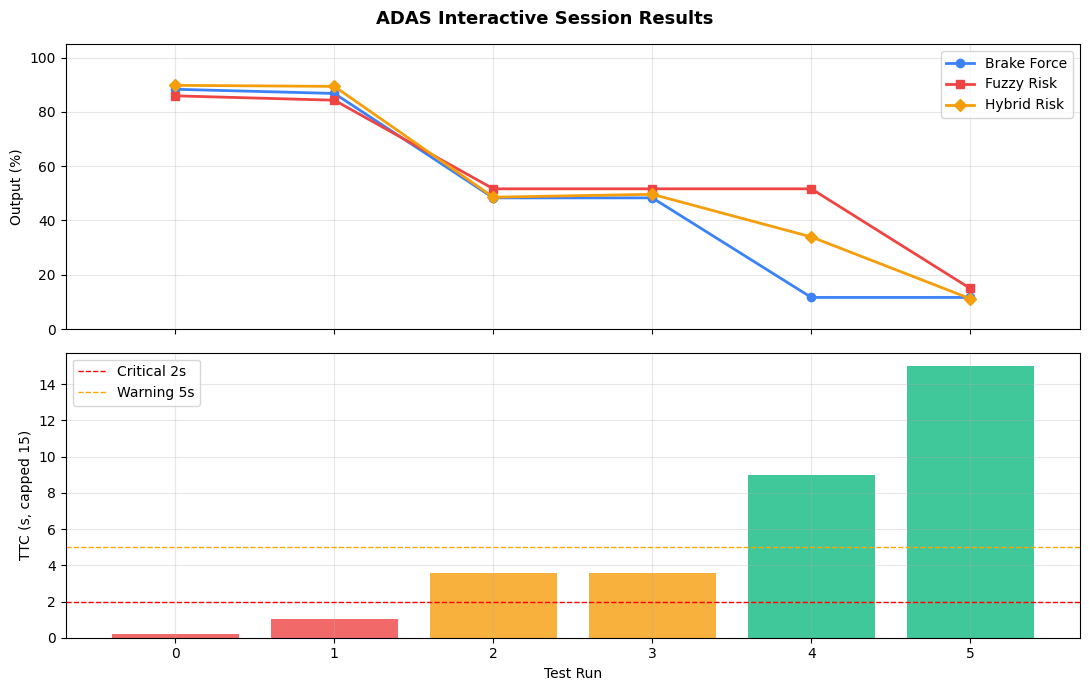


── Results Table ──
 dist  speed  brake  risk  alert  lstm_prob  hybrid_risk  ttc_sec category
  5.0   90.0   88.3  85.9   89.1       98.8         89.8      0.2     HIGH
 20.0   70.0   86.8  84.3   69.8       97.0         89.4      1.0     HIGH
 50.0   50.0   48.3  51.7   50.0       43.9         48.6      3.6 MODERATE
 80.0   80.0   48.3  51.7   89.1       46.6         49.6      3.6 MODERATE
 50.0   20.0   11.7  51.7   11.1        7.4         34.0      9.0      LOW
 95.0   10.0   11.7  15.0   11.1        5.6         11.2     34.2      LOW


In [6]:
# ══════════════════════════════════════════════════════════════
#  PART 4 — INTERACTIVE SIMULATOR  (IMPROVED)
# ══════════════════════════════════════════════════════════════

# ── CELL 14: Interactive Loop ─────────────────────────────────

print("\n" + "=" * 55)
print("  ADAS INTERACTIVE SIMULATOR")
print("  Inputs: distance (m) + relative speed (km/h)")
print("=" * 55)

sim_results = []

while True:
    inp = input("\nDistance (0–100 m) [q to quit]: ").strip()
    if inp.lower() == 'q':
        break
    try:
        d = float(inp)
        s = float(input("Relative speed (0–100 km/h): ").strip())
        if not (0 <= d <= 100 and 0 <= s <= 100):
            print("  ✗ Values must be in range [0, 100]"); continue

        h = hybrid_predict(d, s)
        ttc_str = f"{h['ttc_sec']:.1f}s" if h['ttc_sec'] < 999 else "∞"
        warn = "⚠ EMERGENCY" if h['category'] == 'HIGH' else ("⚡ CAUTION" if h['category'] == 'MODERATE' else "✓ SAFE")

        print(f"\n  {warn}")
        print(f"  ┌─────────────────────────────┐")
        print(f"  │ Brake Force  : {h['brake']:>5.1f}%        │")
        print(f"  │ Fuzzy Risk   : {h['risk']:>5.1f}%        │")
        print(f"  │ Driver Alert : {h['alert']:>5.1f}%        │")
        print(f"  │ LSTM Prob    : {h['lstm_prob']:>5.1f}%        │")
        print(f"  │ Hybrid Risk  : {h['hybrid_risk']:>5.1f}% [{h['category']:<8}]│")
        print(f"  │ TTC          : {ttc_str:>7}         │")
        print(f"  └─────────────────────────────┘")

        sim_results.append({**h, 'dist': d, 'speed': s})
    except ValueError:
        print("  ✗ Invalid input — enter a number")

# Plot interactive session results
if sim_results:
    df = pd.DataFrame(sim_results)
    fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
    fig.suptitle('ADAS Interactive Session Results', fontsize=13, fontweight='bold')

    axes[0].plot(df['brake'],       marker='o', linewidth=2, label='Brake Force',  color='#3b82f6')
    axes[0].plot(df['risk'],        marker='s', linewidth=2, label='Fuzzy Risk',   color='#ef4444')
    axes[0].plot(df['hybrid_risk'], marker='D', linewidth=2, label='Hybrid Risk',  color='#f59e0b')
    axes[0].set_ylabel('Output (%)'); axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_ylim(0,105)

    axes[1].bar(range(len(df)), df['ttc_sec'].clip(0, 15), color=[
        '#ef4444' if t < 2 else '#f59e0b' if t < 5 else '#10b981' for t in df['ttc_sec']
    ], alpha=0.8)
    axes[1].axhline(2, color='red', linestyle='--', linewidth=1, label='Critical 2s')
    axes[1].axhline(5, color='orange', linestyle='--', linewidth=1, label='Warning 5s')
    axes[1].set_xlabel('Test Run'); axes[1].set_ylabel('TTC (s, capped 15)'); axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout(); plt.show()

    print("\n── Results Table ──")
    cols = ['dist','speed','brake','risk','alert','lstm_prob','hybrid_risk','ttc_sec','category']
    print(df[cols].to_string(index=False, float_format=lambda x: f'{x:.1f}'))


